In [38]:
import matplotlib.pyplot as plt
import numpy as np
import mne
from mne.preprocessing import ICA
import pandas as pd
import seaborn as sns
from mne.stats import permutation_cluster_test
from mpl_toolkits.mplot3d import Axes3D

In [39]:
# Stier
bdf_path = r"/content/LuChris_1.bdf"
csv_path = r"/content/data_p9876_20260508_1018.csv"

# Indlæsning af data
raw = mne.io.read_raw_bdf(bdf_path, preload=True)   # .bdf
raw.resample(512)
raw = raw.notch_filter(50)
raw.set_eeg_reference('average', projection=False)
df = pd.read_csv(csv_path)                          # .csv

Extracting BDF parameters from /content/LuChris_1.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6557695  =      0.000 ...  3202.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming wind

In [40]:
# ICA (Independent Component Analysis) For at fjerne øjenblink
raw_ica = raw.copy().filter(l_freq=1.0, h_freq=40.0)
ica = mne.preprocessing.ICA(n_components=20, random_state=42, max_iter='auto')
ica.fit(raw_ica, decim=3)

# Bed MNE om automatisk at finde blink vha. de forreste elektroder.
eog_channels = ['Fp1', 'Fp2', 'Fpz']
try:
    eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=eog_channels)
    print(f"ICA fandt blink i komponent(er): {eog_indices}")
    ica.exclude = eog_indices
except Exception as e:
    print(f"Kunne ikke finde EOG automatisk (tjek elektrodenavne). Kør ica.plot_components(raw) for at vælge manuelt.")

# Filtrer den RIGTIGE data til ERP-brug (0.1 - 30 Hz) og træk blink-komponenterne ud
raw_clean = raw.copy().filter(l_freq=0.1, h_freq=40.0)
ica.apply(raw_clean)

# Find triggers
events = mne.find_events(raw_clean, stim_channel='Status')

# Sikkerhedstjek: Antal triggers fra EEG skal matche antal trials i CSV
if len(events) > len(df):
    print("Fandt ekstra start/stop triggers i EEG'et. Fjerner dem for at matche CSV...")
    events = events[-len(df):]

tmin, tmax = -0.2, 0.8
reject_criteria = dict(eeg=150e-6)

epochs = mne.Epochs(
    raw_clean,
    events,
    metadata = df,
    #event_id=event_dict,
    tmin=tmin,
    tmax=tmax,
    baseline=(tmin, 0), # Nulstil baseline (-0.2 til 0) så alle starter samme sted
    preload=True,
    reject=reject_criteria
)

# Hvilke epochs der er droppet efter ICA
print(epochs.drop_log_stats())


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (3.303 s)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 53.6s.
Using EOG channels: Fp1, Fp2, Fpz
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- 

In [41]:
blocks_to_exclude = [1,2,3,4,5,6,7,11,15,19,23,27]
epochs_main = epochs[f"block_num not in {blocks_to_exclude}"]
epochs_correct = epochs_main["correct == True"]
print(f"Beholder {len(epochs_correct)} trials til selve ERP analysen.")

Beholder 992 trials til selve ERP analysen.



Beregner ERP'er og statistisk signifikans for alle afvigertyper...

Genererer plots for Auditory Deviant (Lyd)...
Using a threshold of 3.852244
stat_fun(H1): min=2.910723192604218e-06 max=12.867507455486688
Running initial clustering …
Found 12 clusters


/tmp/ipykernel_8810/3082088383.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 3.852244
stat_fun(H1): min=3.3678832490611696e-05 max=15.69330506467094
Running initial clustering …
Found 7 clusters


/tmp/ipykernel_8810/3082088383.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

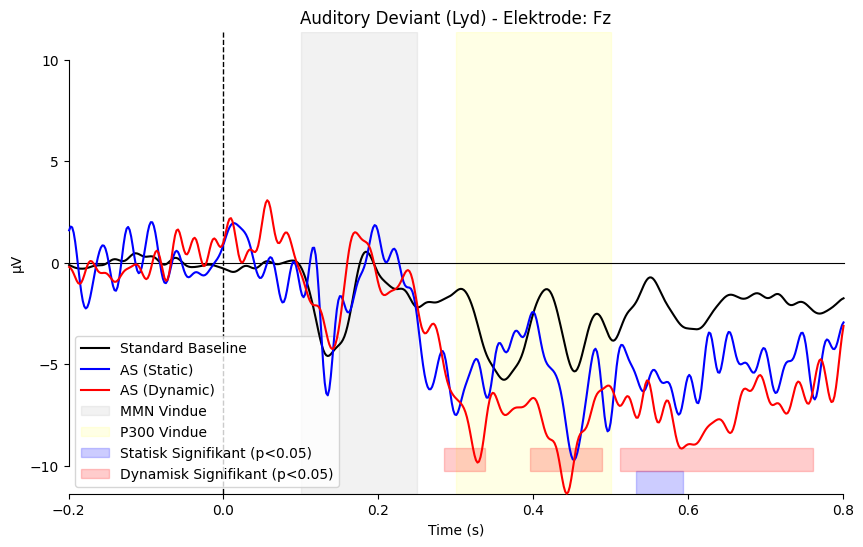

Using a threshold of 3.852244
stat_fun(H1): min=1.7159328666623696e-06 max=9.006747504307398
Running initial clustering …
Found 3 clusters


/tmp/ipykernel_8810/3082088383.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 3.852244
stat_fun(H1): min=3.867020141253295e-07 max=11.737714457738784
Running initial clustering …
Found 3 clusters


/tmp/ipykernel_8810/3082088383.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

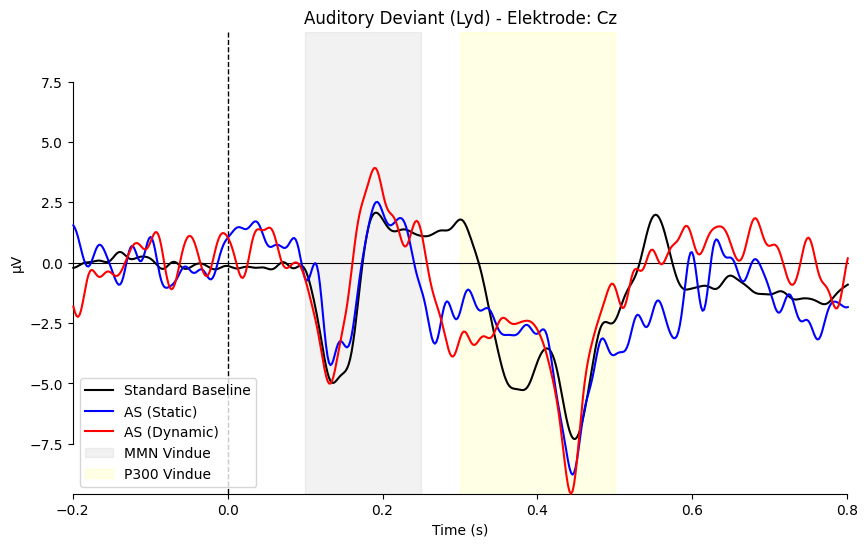


Genererer plots for Visual Deviant (Syn)...
Using a threshold of 3.852332
stat_fun(H1): min=2.9620580372526545e-07 max=11.277848989203504
Running initial clustering …
Found 8 clusters


/tmp/ipykernel_8810/3082088383.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 3.852294
stat_fun(H1): min=9.401768524393507e-05 max=82.0847720650547
Running initial clustering …
Found 9 clusters


/tmp/ipykernel_8810/3082088383.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

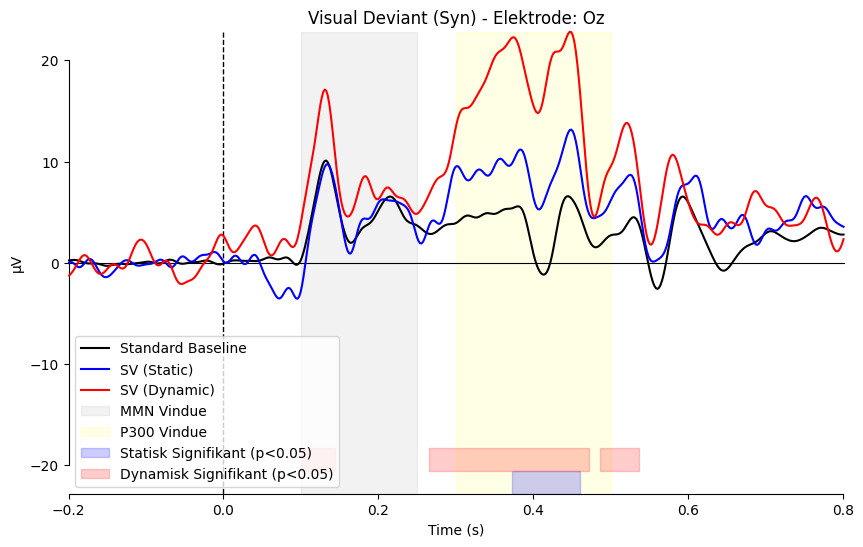

Using a threshold of 3.852332
stat_fun(H1): min=2.2312242792991376e-05 max=8.300548309492195
Running initial clustering …
Found 8 clusters


/tmp/ipykernel_8810/3082088383.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 3.852294
stat_fun(H1): min=0.0003648214767211083 max=46.44771175406036
Running initial clustering …
Found 5 clusters


/tmp/ipykernel_8810/3082088383.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

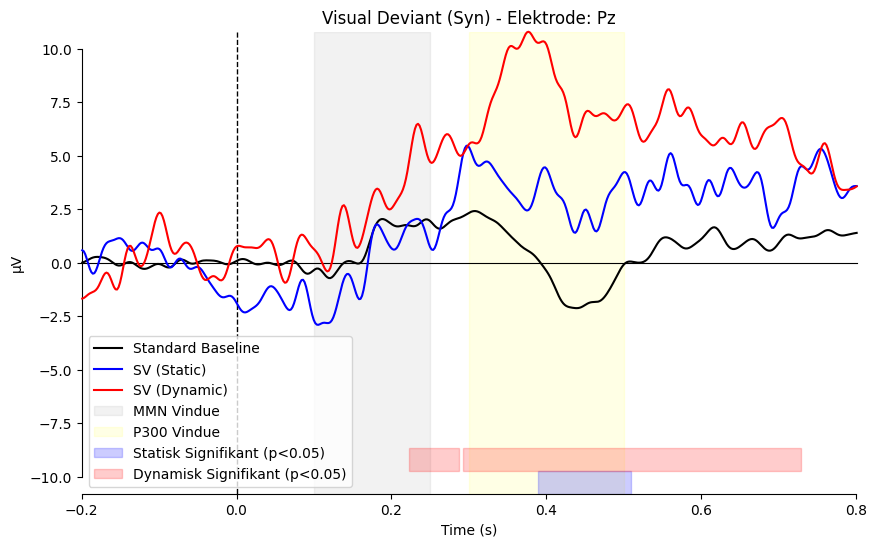


Genererer plots for Multimodal Deviant (Lyd+Syn)...
Using a threshold of 3.852170
stat_fun(H1): min=8.344141382135127e-06 max=8.91356225451386
Running initial clustering …
Found 4 clusters


/tmp/ipykernel_8810/3082088383.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 3.852294
stat_fun(H1): min=4.279198583156511e-06 max=7.935495476061501
Running initial clustering …
Found 9 clusters


/tmp/ipykernel_8810/3082088383.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

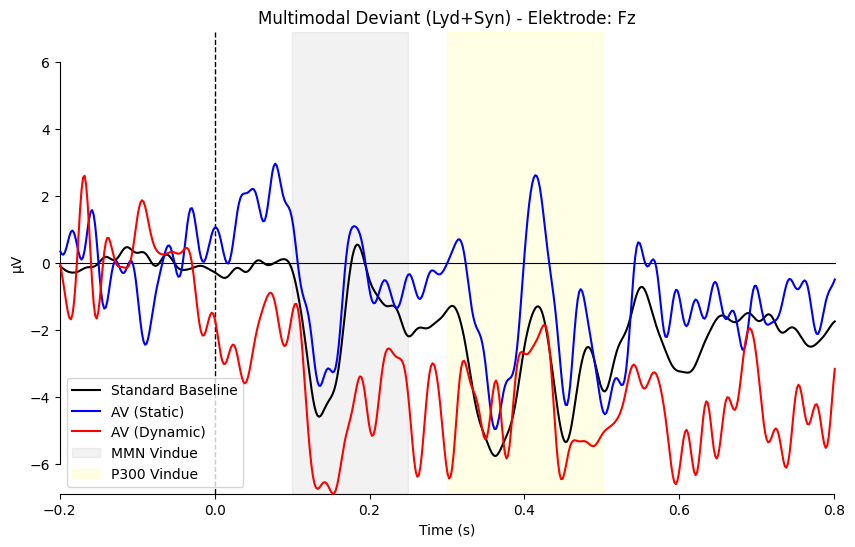

Using a threshold of 3.852170
stat_fun(H1): min=1.445786313920154e-06 max=5.846288794803474
Running initial clustering …
Found 2 clusters


/tmp/ipykernel_8810/3082088383.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 3.852294
stat_fun(H1): min=7.051306508791665e-07 max=10.329620266175729
Running initial clustering …
Found 4 clusters


/tmp/ipykernel_8810/3082088383.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

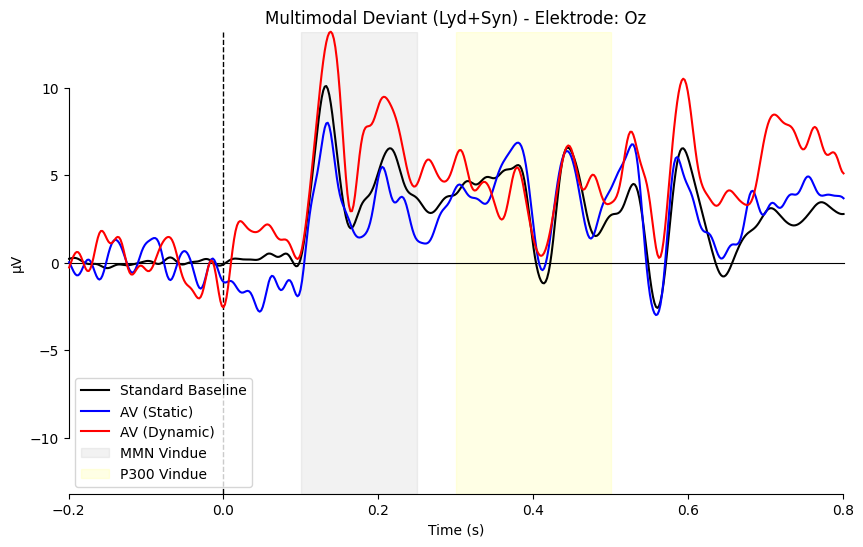

Using a threshold of 3.852170
stat_fun(H1): min=3.4544202754960236e-06 max=7.83201049369101
Running initial clustering …
Found 3 clusters


/tmp/ipykernel_8810/3082088383.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 3.852294
stat_fun(H1): min=7.612811296457049e-07 max=13.289426927609178
Running initial clustering …
Found 6 clusters


/tmp/ipykernel_8810/3082088383.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

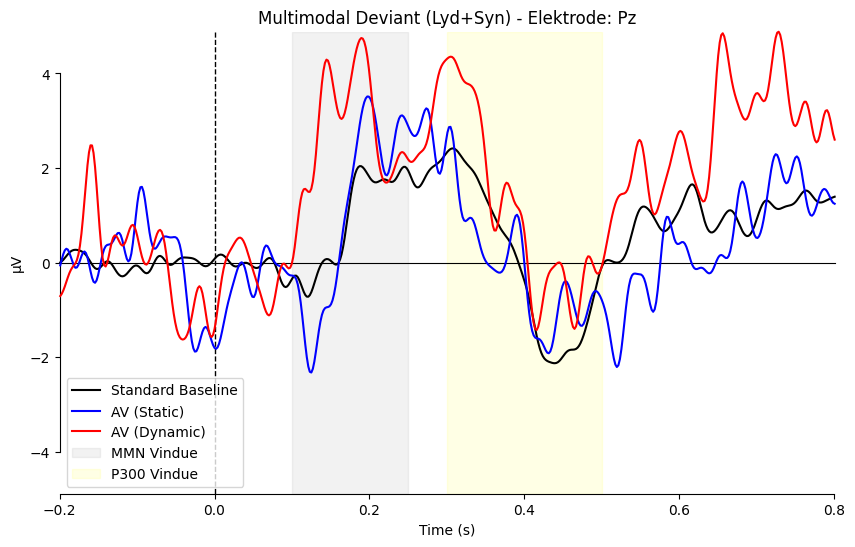

In [42]:
# ==========================================
# 7. ERP PLOTS MED INDBYGGET SIGNIFIKANS
# ==========================================
print("\nBeregner ERP'er og statistisk signifikans for alle afvigertyper...")

cond_standard = epochs_correct["stimulus_state == 'standard'"].average()

deviant_configs = {
    'AS': {
        'name': 'Auditory Deviant (Lyd)',
        'channels': ['Fz', 'Cz']
    },
    'SV': {
        'name': 'Visual Deviant (Syn)',
        'channels': ['Oz', 'Pz']
    },
    'AV': {
        'name': 'Multimodal Deviant (Lyd+Syn)',
        'channels': ['Fz', 'Oz', 'Pz']
    }
}

for dev_type, config in deviant_configs.items():
    print(f"\nGenererer plots for {config['name']}...")

    # Hent selve epoch-dataen (til at regne signifikans)
    epochs_static = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"]
    epochs_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"]
    epochs_std = epochs_correct["stimulus_state == 'standard'"]

    # Hent gennemsnittet (til selve linje-plottet)
    cond_static = epochs_static.average()
    cond_dynamic = epochs_dyn.average()

    evokeds_dict = {
        'Standard Baseline': cond_standard,
        f'{dev_type} (Static)': cond_static,
        f'{dev_type} (Dynamic)': cond_dynamic
    }

    colors = {
        'Standard Baseline': 'black',
        f'{dev_type} (Static)': 'blue',
        f'{dev_type} (Dynamic)': 'red'
    }

    for ch in config['channels']:
        if ch in epochs_correct.ch_names:

            fig, ax = plt.subplots(figsize=(10, 6))

            # --- 1. TEGN SELVE LINJERNE ---
            mne.viz.plot_compare_evokeds(
                evokeds_dict,
                picks=[ch],
                colors=colors,
                axes=ax,
                title=f"{config['name']} - Elektrode: {ch}",
                show_sensors=False,
                show=False # Vent med at vise plottet!
            )

            # --- 2. TEGN MMN/P300 ZONERNE I BAGGRUNDEN ---
            ax.axvspan(0.100, 0.250, color='gray', alpha=0.1, label='MMN Vindue', zorder=0)
            ax.axvspan(0.300, 0.500, color='yellow', alpha=0.1, label='P300 Vindue', zorder=0)

            # --- 3. BEREGN OG TEGN SIGNIFIKANS ---
            ch_idx = epochs_correct.ch_names.index(ch)
            times = epochs_correct.times

            # Data arrays til klyngetesten (squeeze fjerner unødige dimensioner)
            data_std = epochs_std.get_data(picks=ch_idx).squeeze()
            data_stat = epochs_static.get_data(picks=ch_idx).squeeze()
            data_dyn = epochs_dyn.get_data(picks=ch_idx).squeeze()

            # Test: Er STATISK signifikant forskellig fra Standard?
            _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
            if clusters_stat: # Tjek om den overhovedet fandt nogle clusters
                for i_c, c in enumerate(clusters_stat):
                    if p_val_stat[i_c] <= 0.05:
                        start_idx = c[0][0]  # Første index i klyngen
                        stop_idx = c[0][-1]  # Sidste index i klyngen
                        ax.axvspan(times[start_idx], times[stop_idx], color='blue', alpha=0.2, label='Statisk Signifikant (p<0.05)', ymin=0.0, ymax=0.05)

            # Test: Er DYNAMISK signifikant forskellig fra Standard?
            _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
            if clusters_dyn: # Tjek om den overhovedet fandt nogle clusters
                for i_c, c in enumerate(clusters_dyn):
                    if p_val_dyn[i_c] <= 0.05:
                        start_idx = c[0][0]  # Første index i klyngen
                        stop_idx = c[0][-1]  # Sidste index i klyngen
                        ax.axvspan(times[start_idx], times[stop_idx], color='red', alpha=0.2, label='Dynamisk Signifikant (p<0.05)', ymin=0.05, ymax=0.1)

            # Opdater legend og vis grafen
            # For at undgå at signifikans-boksene står 5 gange i boksen, fjerner vi dubletter
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='lower left')

            plt.show()


Beregner antal faktiske afvigere i dataen for alle betingelser...

--- FAKTISK ANTAL DEVIANTS I DATAEN ---
block_type deviant_type  Antal
   Dynamic           AS     27
   Dynamic           AV     23
   Dynamic           SV     23
    Static           AS     27
    Static           AV     33
    Static           SV     20


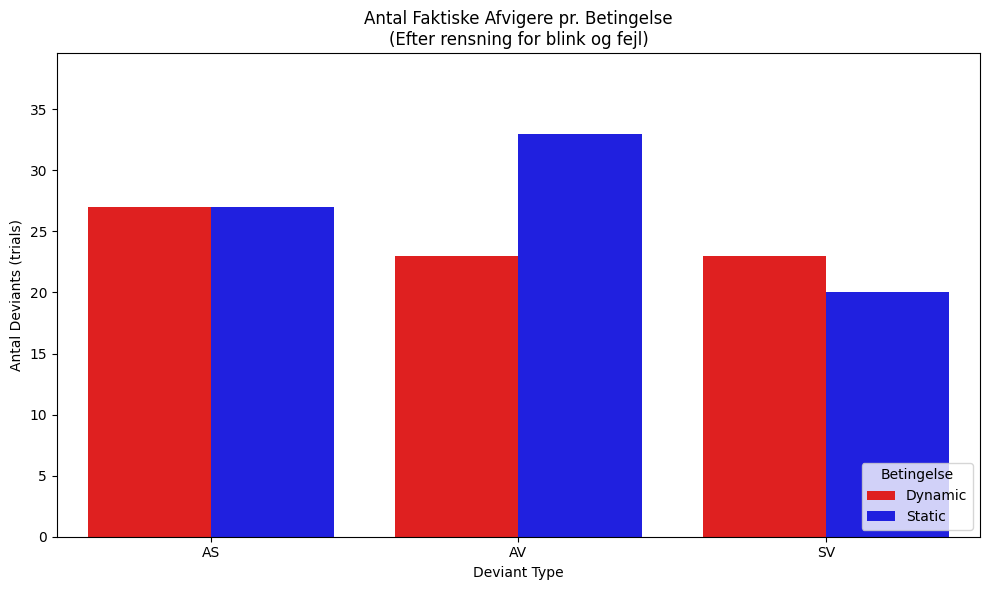

In [43]:
# ==========================================
# 8. TJEK ANTAL DEVIANTS (STATISK VS DYNAMISK)
# ==========================================
print("\nBeregner antal faktiske afvigere i dataen for alle betingelser...")

# Træk den underliggende pandas DataFrame ud fra vores rensede epochs
df_main = epochs_correct.metadata

# Filtrer, så vi KUN kigger på trials, der faktisk var deviants
df_deviants = df_main[df_main['stimulus_state'] == 'deviant']

# Tæl hvor mange der er af hver kombination (block_type x deviant_type)
counts = df_deviants.groupby(['block_type', 'deviant_type']).size().reset_index(name='Antal')

# Print de rå tal i konsollen (Rigtig godt til metodeafsnittet!)
print("\n--- FAKTISK ANTAL DEVIANTS I DATAEN ---")
print(counts.to_string(index=False))

# Lav et flot grupperet bar-plot
plt.figure(figsize=(10, 6))

# Brug 'hue' til at farvekode Statisk/Dynamisk og 'x' til at dele op i AV, SV, AS
sns.barplot(
    data=counts,
    x='deviant_type',
    y='Antal',
    hue='block_type',
    palette={'Static': 'blue', 'Dynamic': 'red'}
)

plt.title('Antal Faktiske Afvigere pr. Betingelse\n(Efter rensning for blink og fejl)')
plt.ylabel('Antal Deviants (trials)')
plt.xlabel('Deviant Type')

# Sæt y-aksen til at starte ved 0 og give lidt luft i toppen
plt.ylim(0, max(counts['Antal']) * 1.2)

# Gør 'legend' (signaturforklaringen) pænere
plt.legend(title='Betingelse', loc='lower right')

plt.tight_layout()
plt.show()

In [44]:
# ==========================================
# 9. MARKOV KÆDER: HAZARD RATE PÅ P300
# ==========================================
import copy

# 1. Frasorter fejl-trials først! (Guldstandard)
epochs_correct = epochs_main["correct == True"]

# 2. Hent metadataen for at tilføje vores tæller
m = epochs_correct.metadata.copy()

# 3. Kør igennem alle trials og tæl hvor mange standarder, der har været i træk
run_lengths = []
current_run = 0

for state in m['stimulus_state']:
    if state == 'standard':
        current_run += 1
        run_lengths.append(current_run)
    else: # Hvis det er en deviant
        # Gem hvor mange standarder der kom LIGE FØR denne deviant
        run_lengths.append(current_run)
        current_run = 0 # Nulstil tælleren

# Tilføj den nye kolonne til vores metadata
m['run_length'] = run_lengths
epochs_correct.metadata = m

Replacing existing metadata with 11 columns



Beregner ERP for Hazard Rate (Tidlig vs Sen Afviger)...


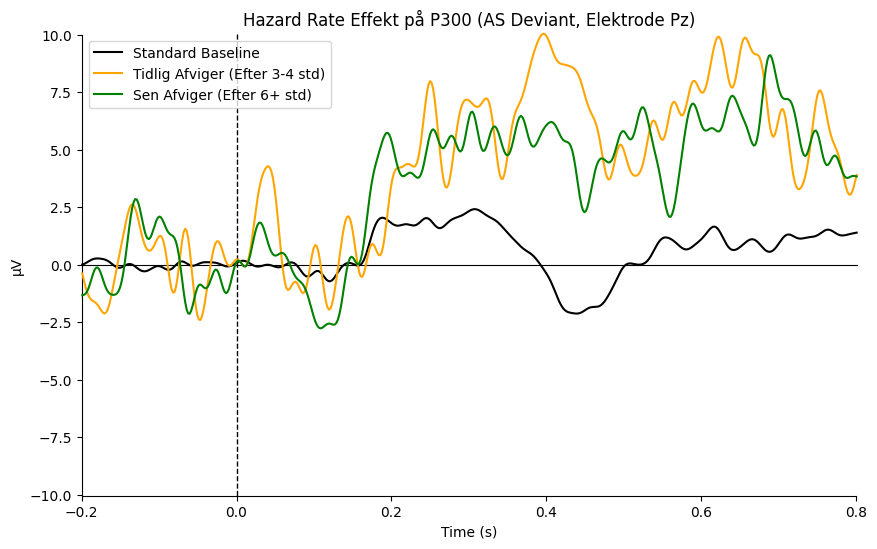

In [45]:
# ==========================================
# PLOT: TIDLIG VS SEN AFVIGER (Kun Dynamiske Blokke)
# ==========================================
print("\nBeregner ERP for Hazard Rate (Tidlig vs Sen Afviger)...")

# Vi kigger kun på 'AV' (Multimodal) i de Dynamiske blokke, da det ofte giver det klareste P300
# Du kan ændre 'AV' til 'SV' eller 'AS'
valgt_afviger = 'AS'

# "Tidlige" afvigere: Kom efter kun 3 eller 4 standarder (Høj surprisal / stor overraskelse)
cond_early = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{valgt_afviger}' and stimulus_state == 'deviant' and run_length <= 4"].average()

# "Sene" afvigere: Kom efter 6 eller flere standarder (Lav surprisal / forventet)
cond_late = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{valgt_afviger}' and stimulus_state == 'deviant' and run_length >= 6"].average()

# Den sorte baseline til sammenligning
cond_standard = epochs_correct["stimulus_state == 'standard'"].average()

evokeds_hazard = {
    'Standard Baseline': cond_standard,
    'Tidlig Afviger (Efter 3-4 std)': cond_early,
    'Sen Afviger (Efter 6+ std)': cond_late
}

colors = {
    'Standard Baseline': 'black',
    'Tidlig Afviger (Efter 3-4 std)': 'orange',
    'Sen Afviger (Efter 6+ std)': 'green'
}

# Plot Pz for P300
fig, ax = plt.subplots(figsize=(10, 6))
mne.viz.plot_compare_evokeds(
    evokeds_hazard,
    picks=['Pz'],
    colors=colors,
    axes=ax,
    title=f'Hazard Rate Effekt på P300 ({valgt_afviger} Deviant, Elektrode Pz)',
    show_sensors=False
)

ax.axvspan(0.300, 0.500, color='yellow', alpha=0.2, label='P300 Vindue')
ax.legend(loc='lower left')
plt.show()



Genererer Topografiske kort...


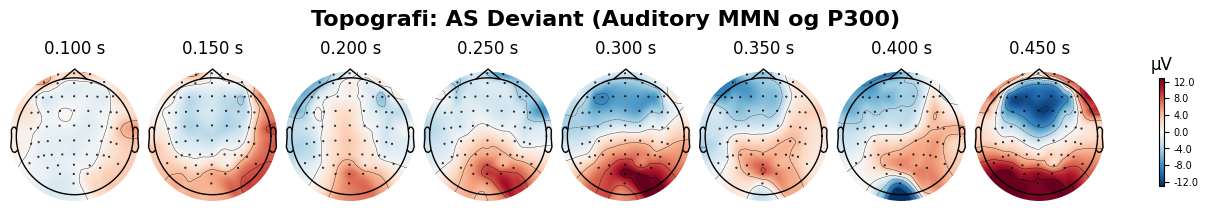

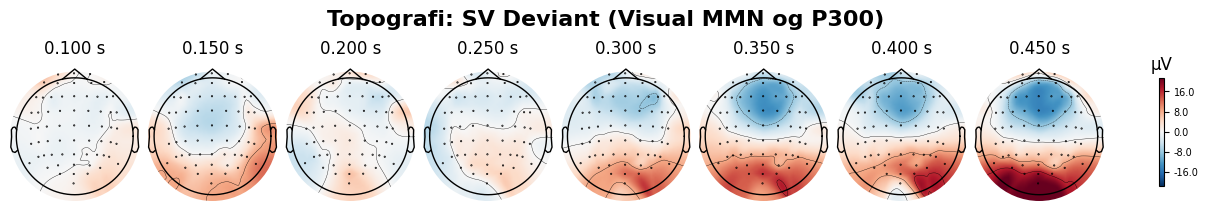

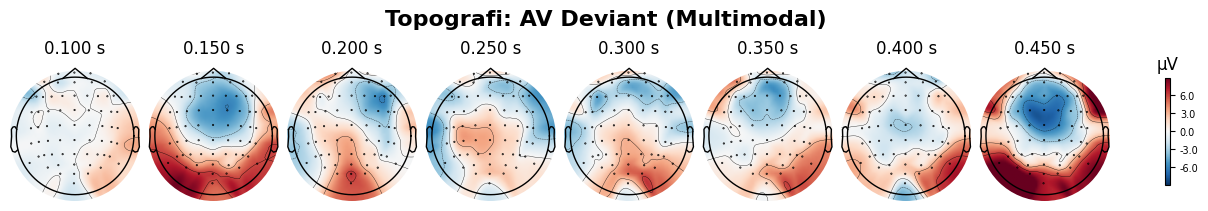

In [46]:
# ==========================================
# 10. TOPOGRAFISKE KORT (TOPOPLOTS)
# ==========================================
print("\nGenererer Topografiske kort...")

try:
    epochs_correct.set_montage('standard_1020')
except ValueError as e:
    print("Bemærk: Kanaler hedder nok noget lokalt (BioSemi), de mangler montage.")

evoked_as = epochs_correct["deviant_type == 'AS' and stimulus_state == 'deviant'"].average()
evoked_sv = epochs_correct["deviant_type == 'SV' and stimulus_state == 'deviant'"].average()
evoked_av = epochs_correct["deviant_type == 'AV' and stimulus_state == 'deviant'"].average()

times_to_plot = [0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400, 0.450]

# --- Plot AS ---
# Vi fanger 'fig' (figuren) som funktionen returnerer
fig_as = evoked_as.plot_topomap(times=times_to_plot, ch_type='eeg', time_unit='s', show=False)
# Sæt den overordnede titel på selve figuren
fig_as.suptitle("Topografi: AS Deviant (Auditory MMN og P300)", fontsize=16, fontweight='bold')

# --- Plot SV ---
fig_sv = evoked_sv.plot_topomap(times=times_to_plot, ch_type='eeg', time_unit='s', show=False)
fig_sv.suptitle("Topografi: SV Deviant (Visual MMN og P300)", fontsize=16, fontweight='bold')

# --- Plot AV ---
fig_av = evoked_av.plot_topomap(times=times_to_plot, ch_type='eeg', time_unit='s', show=False)
fig_av.suptitle("Topografi: AV Deviant (Multimodal)", fontsize=16, fontweight='bold')

# Vis dem alle sammen på én gang
plt.show()


Genererer 3D Entropi Landskab for P300...


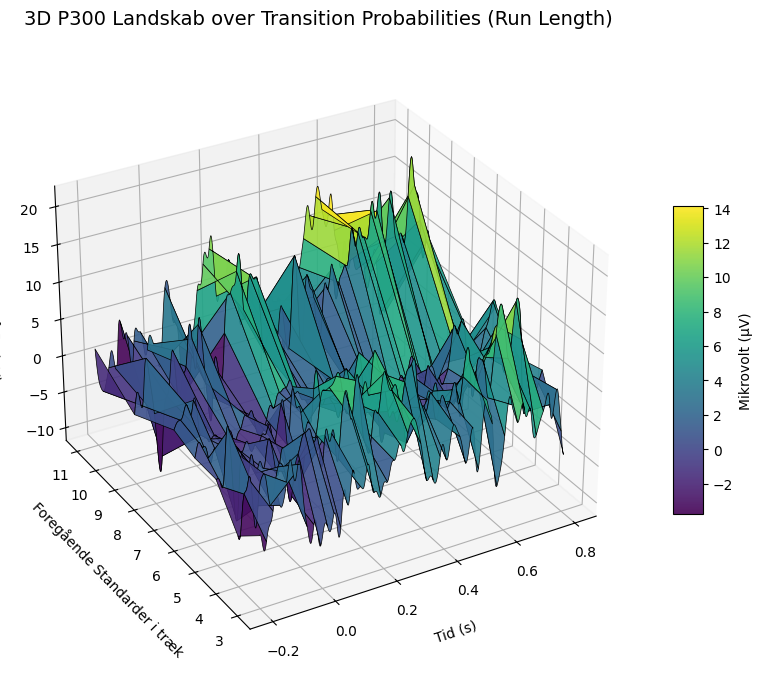

In [47]:
# ==========================================
# 11. 3D ENTOPI / SURPRISAL PLOT (P300)
# ==========================================
print("\nGenererer 3D Entropi Landskab for P300...")

epochs_dyn_av = epochs_correct["block_type == 'Dynamic' and deviant_type == 'AV' and stimulus_state == 'deviant'"]
ch_idx = epochs_correct.ch_names.index('Pz')
times = epochs_correct.times

# Saml de unikke 'run lengths' (vores entropi akse)
unique_runs = np.sort(epochs_dyn_av.metadata['run_length'].unique())

# Vi bygger en Z-matrix der skal holde alle mikrovolt-værdierne
Z_data = []
valid_runs = []

for run_len in unique_runs:
    data_for_run = epochs_dyn_av[f"run_length == {run_len}"].get_data(picks=ch_idx).squeeze()

    # Sikkerhedstjek: Spring over hvis der ikke er noget data
    if data_for_run.size == 0:
        continue

    if data_for_run.ndim == 1:
        mean_erp = data_for_run * 1e6
    else:
        mean_erp = data_for_run.mean(axis=0) * 1e6

    Z_data.append(mean_erp)
    valid_runs.append(run_len)

# Konverter til Numpy arrays
Z = np.array(Z_data)

# Skab et 2D gitter (Meshgrid) for X (Tid) og Y (Run Length)
X, Y = np.meshgrid(times, valid_runs)

# Sæt 3D figuren op
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot LANDSKABET (plot_surface)
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='k', linewidth=0.5, alpha=0.9)

ax.set_title("3D P300 Landskab over Transition Probabilities (Run Length)", pad=20, fontsize=14)
ax.set_xlabel("Tid (s)", labelpad=10)
ax.set_ylabel("Foregående Standarder i træk", labelpad=10)
ax.set_zlabel("Amplitude på Pz (µV)", labelpad=10)

# Tilføj en farveskala (colorbar) til højre for plottet
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Mikrovolt (µV)')

# Roter kameraet lidt for at give den bedste vinkel
ax.view_init(elev=30, azim=-120)

plt.show()


Beregner Difference Waves (Det rene overraskelses-signal)...

Genererer Difference Waves for Auditory Deviant...


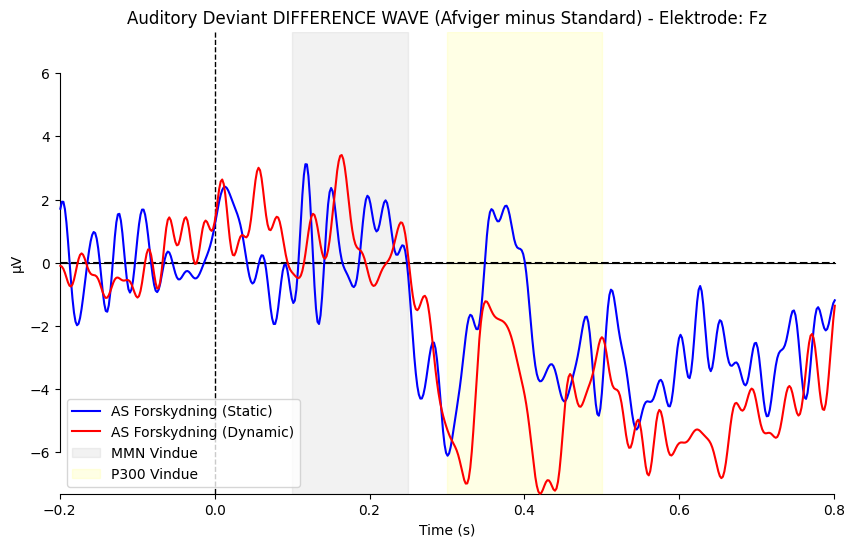

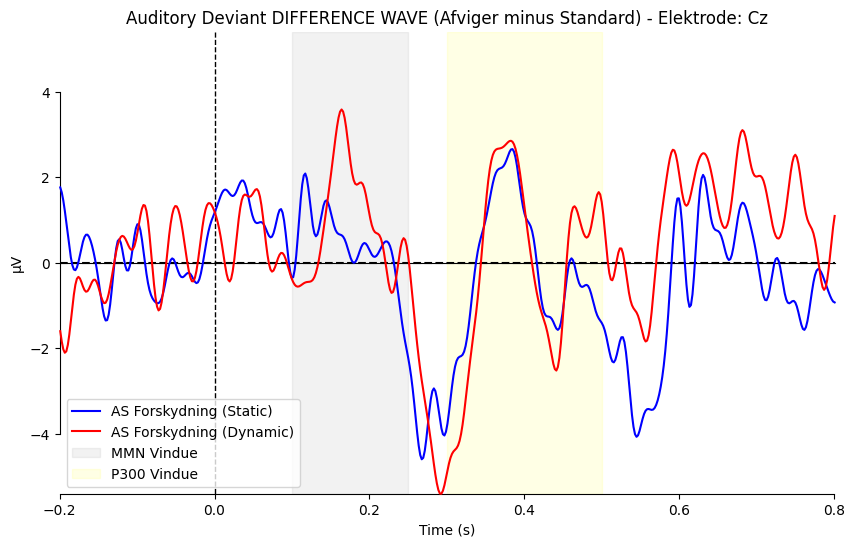


Genererer Difference Waves for Visual Deviant...


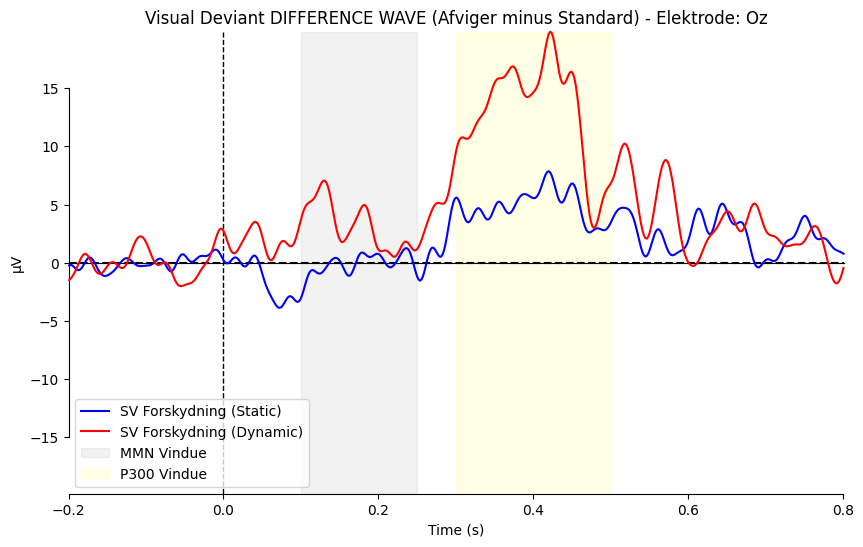

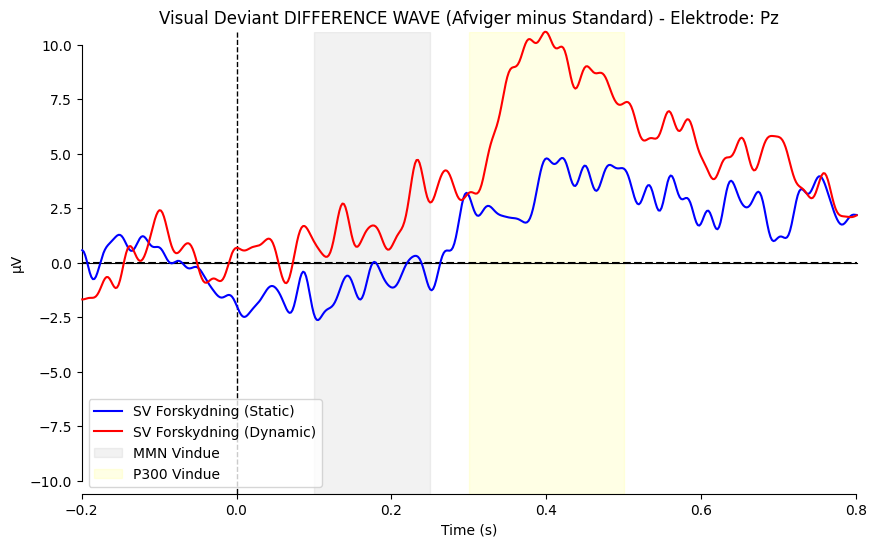


Genererer Difference Waves for Multimodal Deviant...


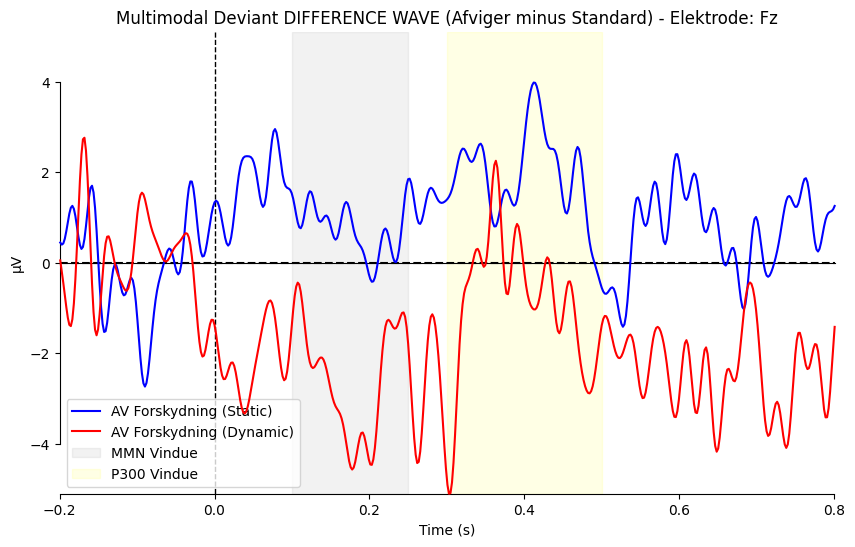

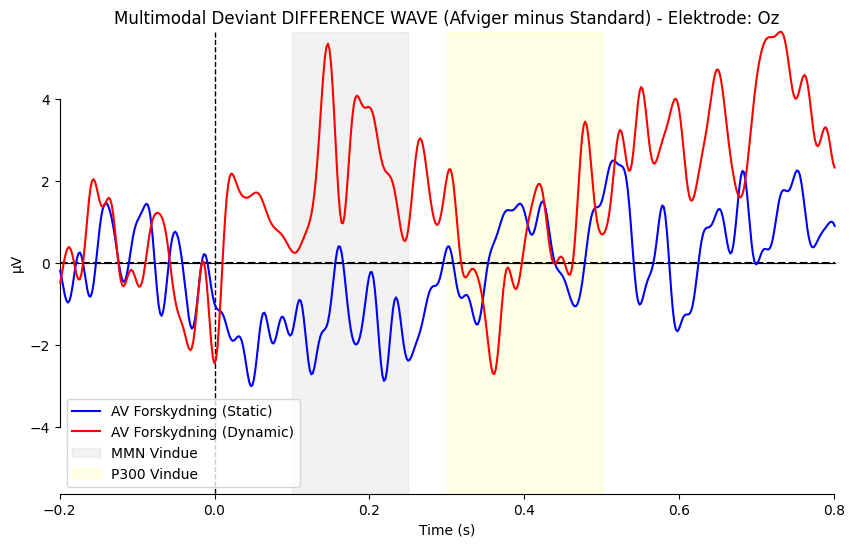

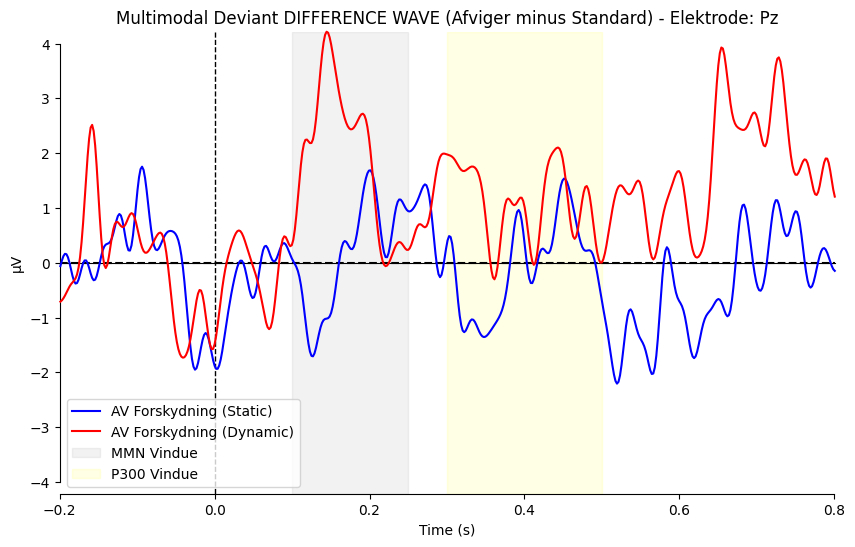

In [48]:
# ==========================================
# 12. DIFFERENCE WAVES (AFVIGER MINUS STANDARD)
# ==========================================
print("\nBeregner Difference Waves (Det rene overraskelses-signal)...")

# Vi skal bruge standarden til at trække fra alle andre
evoked_std = epochs_correct["stimulus_state == 'standard'"].average()

# Vi genbruger din opsætning for elektroderne
deviant_configs = {
    'AS': {'name': 'Auditory Deviant', 'channels': ['Fz', 'Cz']},
    'SV': {'name': 'Visual Deviant', 'channels': ['Oz', 'Pz']},
    'AV': {'name': 'Multimodal Deviant', 'channels': ['Fz', 'Oz', 'Pz']}
}

for dev_type, config in deviant_configs.items():
    print(f"\nGenererer Difference Waves for {config['name']}...")

    # Hent de rene afvigere
    evoked_stat = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()
    evoked_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()

    # BEREGN FORSKELLEN: MNE trækker værdien for standard (vægt -1) fra afvigeren (vægt 1)
    diff_stat = mne.combine_evoked([evoked_stat, evoked_std], weights=[1, -1])
    diff_dyn = mne.combine_evoked([evoked_dyn, evoked_std], weights=[1, -1])

    # Saml dem til plottet
    diff_dict = {
        f'{dev_type} Forskydning (Static)': diff_stat,
        f'{dev_type} Forskydning (Dynamic)': diff_dyn
    }

    colors = {
        f'{dev_type} Forskydning (Static)': 'blue',
        f'{dev_type} Forskydning (Dynamic)': 'red'
    }

    for ch in config['channels']:
        if ch in epochs_correct.ch_names:

            fig, ax = plt.subplots(figsize=(10, 6))

            # Tegn en vandret sort, stiplet linje ved NUL (0 mikrovolt)
            # På en difference wave betyder 0, at hjernen reagerede PRÆCIS ens på standard og afviger!
            ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)

            mne.viz.plot_compare_evokeds(
                diff_dict,
                picks=[ch],
                colors=colors,
                axes=ax,
                title=f"{config['name']} DIFFERENCE WAVE (Afviger minus Standard) - Elektrode: {ch}",
                show_sensors=False,
                show=False
            )

            # Tegn zonerne i baggrunden
            ax.axvspan(0.100, 0.250, color='gray', alpha=0.1, label='MMN Vindue', zorder=0)
            ax.axvspan(0.300, 0.500, color='yellow', alpha=0.1, label='P300 Vindue', zorder=0)

            # Ryd op i legend (Så den sorte "baseline" linje ikke står der to gange)
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='lower left')

            plt.show()